# Layer-1 and Layer-2 Cross-Head Mean-Attention Ablation — Query Position 2

**Goal:** Companion to `layer_1_and_2_attention_ablation.ipynb`. That notebook *masked*
attention from a query position back to earlier key positions (pre-softmax, additive
`attention_mask`), forcing softmax to redistribute weight onto the unmasked key(s).

This notebook does something different: for query position 2 (the last of 3 tokens),
for **each key position** (0, 1, and 2), compute the **mean across all 32 heads** of
that key's post-softmax attention score, then write that same head-averaged value back
into **every head** at that key position. The result: all 32 heads end up with an
identical attention distribution over the 3 keys — the cross-head average — rather
than each head keeping its own distribution. This is done only within layer 1 and
layer 2 (Dr. Liu's 1-indexed convention, i.e. HF 0-indexed `model.model.layers[0]` and
`model.model.layers[1]`).

**Why this can't reuse the masking notebook's hook.** `make_block_hook` works entirely
through the additive `attention_mask` kwarg, applied *before* softmax — fine for
zeroing specific entries, since softmax renormalizes the rest automatically. But
"replace with the cross-head mean" is a *post-softmax* operation with no equivalent
additive offset, so this notebook patches `LlamaAttention.forward` itself — the
method that computes softmax and the value-weighted sum — rather than editing the
mask kwarg.

**Important contrast with an earlier (wrong) version of this experiment.** An earlier
draft averaged *within* each head, across keys. Since a single head's post-softmax
weights for one query always sum to 1, averaging a head's own 3 values is
mathematically forced to give exactly 1/3 regardless of the data — that version was
secretly just testing uniform attention, not anything data-dependent. Averaging
*across heads* for a fixed key, as done here, has no such constraint: there's nothing
forcing 32 different heads' scores at key 0 to sum to any particular value, so the
cross-head mean genuinely reflects the model's learned attention pattern rather than
being a foregone conclusion.

**Indexing note:** `LAYERS_TO_TEST = [0, 1]` are 0-indexed HF layers, corresponding to
Dr. Liu's 1-indexed "layer 1" and "layer 2" — same convention as the masking notebook.

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import os
import contextlib
from transformers import AutoModelForCausalLM, AutoTokenizer
import transformers.models.llama.modeling_llama as llama_modeling

MODEL_PATH = "/home/samuel/research/llmattacks/llm-attacks/DIR/Llama-3.1-8B-Instruct"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.bfloat16

# 0-indexed HF layers to intervene on.
# LAYERS_TO_TEST[0] == 0 -> Dr. Liu's 1-indexed "layer 1"
# LAYERS_TO_TEST[1] == 1 -> Dr. Liu's 1-indexed "layer 2"
LAYERS_TO_TEST = [0, 1]
LAYER_LABELS = {0: "layer 1", 1: "layer 2"}

# EXPLICIT_QUERY_POSITIONS = [12, 18]
NEURON_IDX = 2427          # MA-implicated gate neuron

OUTPUT_DIR = "outputs/mean_attention_ablation"
os.makedirs(OUTPUT_DIR, exist_ok=True)

torch.manual_seed(0)

In [2]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    torch_dtype=DTYPE,
    attn_implementation="eager",  # required: LlamaAttention.forward is the patch target
).to(DEVICE)
model.eval()
print(model.config.num_hidden_layers, "layers | hidden_size:", model.config.hidden_size)

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

32 layers | hidden_size: 4096


## Prepare input — exactly 3 tokens

Same convention as the masking notebook: `add_special_tokens=False` with an explicit
BOS check. `QUERY_POS = 2` requires the sequence to have at least 3 tokens; here we use
exactly 3, matching "three tokens [0, 1, 2] in total."

In [3]:
# PROMPT = "Tell me joke"  # placeholder -- replace with a real 3-token example
PROMPT = ("Florida State University is ranked No. 21 among top public universities "
          "in the United States according to the U.S. News & World Report.")

BOS_ID = tokenizer.bos_token_id
ids = tokenizer.encode(PROMPT, add_special_tokens=False)
assert ids[0] != BOS_ID, "First token unexpectedly matches BOS id -- check tokenizer/prompt"
# assert len(ids) == 3, f"Expected exactly 3 tokens, got {len(ids)}: {ids}. Adjust PROMPT."

QUERY_POS = len(ids)-1 # Variable now
KEY_POSITIONS = [i for i in range(0, QUERY_POS + 1)]   # replace ALL of them with their per-head mean



input_ids = torch.tensor([ids], device=DEVICE)
tokens_decoded = [tokenizer.decode([t]) for t in ids]
print("token ids:", ids)
print("tokens:   ", tokens_decoded)

token ids: [58127, 3314, 3907, 374, 21682, 2360, 13, 220, 1691, 4315, 1948, 586, 23978, 304, 279, 3723, 4273, 4184, 311, 279, 549, 815, 13, 5513, 612, 4435, 8423, 13]
tokens:    ['Florida', ' State', ' University', ' is', ' ranked', ' No', '.', ' ', '21', ' among', ' top', ' public', ' universities', ' in', ' the', ' United', ' States', ' according', ' to', ' the', ' U', '.S', '.', ' News', ' &', ' World', ' Report', '.']


## Helpers — cross-head mean-replace patch and activation capture

`make_mean_replace_forward` is a drop-in replacement for
`transformers.models.llama.modeling_llama.LlamaAttention.forward`. The installed
transformers version (4.46.3) computes eager attention inline inside this method —
there is no standalone `eager_attention_forward` function to patch (that factoring was
introduced in later transformers releases). This reimplementation is identical to the
original up through softmax; the only change is that for any layer in
`layers_to_patch`, the attention weights at `query_pos` are averaged **across the head
dimension**, independently for each key position in `key_positions`, and that
head-averaged value is written back into every head. All 32 heads end up sharing the
same (data-dependent) distribution over those keys. Monkeypatching the class attribute
`llama_modeling.LlamaAttention.forward` takes effect immediately for every layer's
`forward()`, since all decoder layers share the same class.

`capture_activations` is unchanged from before: hooks `mlp` on each layer in
`capture_layers` to grab the post-RMSNorm input and compute the gate vector
`x @ W_gate.T`, optionally with the patch active for `mean_replace_layers`.

In [4]:
_ORIGINAL_LLAMA_ATTENTION_FORWARD = llama_modeling.LlamaAttention.forward


def make_mean_replace_forward(layers_to_patch, query_pos, key_positions):
    key_idx = torch.tensor(key_positions)

    def patched_forward(
        self,
        hidden_states,
        attention_mask=None,
        position_ids=None,
        past_key_value=None,
        output_attentions=False,
        use_cache=False,
        cache_position=None,
        position_embeddings=None,
        **kwargs,
    ):
        bsz, q_len, _ = hidden_states.size()

        query_states = self.q_proj(hidden_states)
        key_states = self.k_proj(hidden_states)
        value_states = self.v_proj(hidden_states)

        query_states = query_states.view(bsz, q_len, self.num_heads, self.head_dim).transpose(1, 2)
        key_states = key_states.view(bsz, q_len, self.num_key_value_heads, self.head_dim).transpose(1, 2)
        value_states = value_states.view(bsz, q_len, self.num_key_value_heads, self.head_dim).transpose(1, 2)

        if position_embeddings is None:
            cos, sin = self.rotary_emb(value_states, position_ids)
        else:
            cos, sin = position_embeddings
        query_states, key_states = llama_modeling.apply_rotary_pos_emb(query_states, key_states, cos, sin)

        if past_key_value is not None:
            cache_kwargs = {"sin": sin, "cos": cos, "cache_position": cache_position}
            key_states, value_states = past_key_value.update(key_states, value_states, self.layer_idx, cache_kwargs)

        key_states = llama_modeling.repeat_kv(key_states, self.num_key_value_groups)
        value_states = llama_modeling.repeat_kv(value_states, self.num_key_value_groups)

        attn_weights = torch.matmul(query_states, key_states.transpose(2, 3)) / (self.head_dim ** 0.5)
        if attention_mask is not None:
            causal_mask = attention_mask[:, :, :, : key_states.shape[-2]]
            attn_weights = attn_weights + causal_mask
        attn_weights = F.softmax(attn_weights, dim=-1, dtype=torch.float32).to(query_states.dtype)

        layer_idx = getattr(self, "layer_idx", None)
        if layer_idx in layers_to_patch:
            idx = key_idx.to(attn_weights.device)
            # (batch, heads, len(key_positions)) -- every head's own scores at these keys
            vals = attn_weights[:, :, query_pos, idx]
            num_heads = vals.shape[1]
            # mean ACROSS HEADS (dim=1), independently per key position -- NOT across keys.
            # (batch, 1, len(key_positions)) -> broadcast the same value to every head
            mean_over_heads = vals.mean(dim=1, keepdim=True)
            attn_weights[:, :, query_pos, idx] = mean_over_heads.expand(-1, num_heads, -1)

        attn_weights = F.dropout(attn_weights, p=self.attention_dropout, training=self.training)
        attn_output = torch.matmul(attn_weights, value_states)

        attn_output = attn_output.transpose(1, 2).contiguous()
        attn_output = attn_output.reshape(bsz, q_len, -1)
        attn_output = self.o_proj(attn_output)

        if not output_attentions:
            attn_weights = None

        return attn_output, attn_weights, past_key_value

    return patched_forward


@contextlib.contextmanager
def mean_replace_attention(layers_to_patch, query_pos, key_positions):
    llama_modeling.LlamaAttention.forward = make_mean_replace_forward(
        set(layers_to_patch), query_pos, key_positions
    )
    try:
        yield
    finally:
        llama_modeling.LlamaAttention.forward = _ORIGINAL_LLAMA_ATTENTION_FORWARD


def capture_activations(model, input_ids, capture_layers, query_pos, mean_replace_layers=None):
    """
    Runs a single forward pass. If mean_replace_layers is given, the cross-head
    mean-replace patch is active for those HF layer indices for the duration of the
    pass. Returns (results, hidden_states):
      - results: {L: {'gate': (14336,), 'attn': (n_heads, seq)}} for every L in
        capture_layers, read out at position query_pos.
      - hidden_states: tuple of length num_layers + 1, each (1, T, d) float32 CPU
        tensor -- hidden_states[0] is the embedding output, hidden_states[l] is the
        residual stream after decoder layer l -- same format `output_hidden_states=True`
        returns in the Finding-MA notebook, captured here under whatever ablation
        (mean_replace_layers) is active for this forward pass.
    """
    captured = {}
    handles = []

    def make_mlp_input_hook(L):
        def hook(module, args):
            captured[('mlp_input', L)] = args[0].detach()
        return hook

    for L in capture_layers:
        handles.append(model.model.layers[L].mlp.register_forward_pre_hook(make_mlp_input_hook(L)))

    cm = (
        mean_replace_attention(mean_replace_layers, QUERY_POS, KEY_POSITIONS)
        if mean_replace_layers is not None
        else contextlib.nullcontext()
    )

    try:
        with cm, torch.no_grad():
            out = model(input_ids=input_ids, output_attentions=True, output_hidden_states=True)
    finally:
        for h in handles:
            h.remove()

    results = {}
    for L in capture_layers:
        x = captured[('mlp_input', L)][0, query_pos, :].to(torch.float32)
        W_gate = model.model.layers[L].mlp.gate_proj.weight.detach().to(torch.float32)
        gate_vec = x @ W_gate.T

        attn_pattern_L = out.attentions[L][0, :, query_pos, :].to(torch.float32)

        results[L] = dict(
            gate=gate_vec.cpu().numpy(),
            attn=attn_pattern_L.cpu().numpy(),
        )

    hidden_states = tuple(h.detach().to(torch.float32).cpu() for h in out.hidden_states)
    return results, hidden_states

## Steps 1–2 — Independent single-layer cross-head mean-replace: layer 1 alone, then layer 2 alone

Same structure as the masking notebook: for each `L` in `LAYERS_TO_TEST`, run a
baseline pass (no patch) and an intervention pass (cross-head mean-replace patch active
at layer `L` only), each a fresh forward call. Results stored in `results[L]`.

Sanity check to watch for: in the intervention attention pattern, all 32 rows (heads)
at query position 2 should now be **identical to each other** — same 3 numbers repeated
32 times — but that shared row is *not* expected to be `[0.333, 0.333, 0.333]`; it
should equal the column-wise average of the baseline pattern shown above. Verify this
numerically against the baseline before trusting any gate-vector numbers.

In [5]:
results = {}
hidden_states_store = {}  # {L: {'baseline': tuple(len num_layers+1, (1,T,d)), 'intervention': ...}}
HIDDEN_STATES_DIR = os.path.join(OUTPUT_DIR, "hidden_states")
os.makedirs(HIDDEN_STATES_DIR, exist_ok=True)

for L in LAYERS_TO_TEST:
    label = LAYER_LABELS[L]
    print(f"\n=== query pos {QUERY_POS}, {label} (HF index {L}), independent cross-head mean-replace ===")

    baseline, baseline_hs = capture_activations(model, input_ids, capture_layers=[L], query_pos=QUERY_POS)
    intervention, intervention_hs = capture_activations(
        model, input_ids, capture_layers=[L], query_pos=QUERY_POS, mean_replace_layers={L}
    )

    baseline_attn = baseline[L]['attn'][:, :len(KEY_POSITIONS)]
    expected_row = baseline_attn.mean(axis=0)  # cross-head mean, per key position

    print(f"baseline attn pattern at {label}, query pos {QUERY_POS} (per head, keys 0..{len(KEY_POSITIONS)-1}):")
    with np.printoptions(suppress=True, precision=4):
        print(baseline_attn)
    print(f"expected shared row after patch (column-wise mean across heads): {np.round(expected_row, 4)}")
    print(f"gate_baseline[neuron {NEURON_IDX}] = {baseline[L]['gate'][NEURON_IDX]:.4f}")

    interv_attn = intervention[L]['attn'][:, :len(KEY_POSITIONS)]
    print(f"intervention attn pattern at {label}, query pos {QUERY_POS} (per head, keys 0..{len(KEY_POSITIONS)-1}):")
    with np.printoptions(suppress=True, precision=4):
        print(interv_attn)
    rows_identical = np.allclose(interv_attn, interv_attn[0], atol=1e-3)
    matches_expected = np.allclose(interv_attn[0], expected_row, atol=1e-3)
    print(f"-> all 32 heads identical: {rows_identical} | matches cross-head baseline mean: {matches_expected}")
    print(f"gate_intervention[neuron {NEURON_IDX}] = {intervention[L]['gate'][NEURON_IDX]:.4f}")

    results[L] = {'baseline': baseline[L], 'intervention': intervention[L]}
    hidden_states_store[L] = {'baseline': baseline_hs, 'intervention': intervention_hs}

    torch.save(baseline_hs, os.path.join(HIDDEN_STATES_DIR, f"hidden_states_baseline_{label.replace(' ', '_')}.pt"))
    torch.save(
        intervention_hs,
        os.path.join(HIDDEN_STATES_DIR, f"hidden_states_intervention_{label.replace(' ', '_')}.pt"),
    )
    print(f"saved hidden_states ({len(baseline_hs)} tensors, shape {tuple(baseline_hs[0].shape)}) to {HIDDEN_STATES_DIR}")


=== query pos 27, layer 1 (HF index 0), independent cross-head mean-replace ===
baseline attn pattern at layer 1, query pos 27 (per head, keys 0..27):
[[0.0007 0.0008 0.0029 0.0023 0.0076 0.0019 0.0033 0.0019 0.0061 0.0097
  0.0093 0.0069 0.0135 0.0114 0.0135 0.0131 0.0206 0.0493 0.033  0.0299
  0.0309 0.0742 0.1895 0.0791 0.1621 0.0559 0.0596 0.1113]
 [0.0101 0.0086 0.0291 0.0161 0.0206 0.0118 0.0742 0.0096 0.0109 0.0177
  0.009  0.0123 0.03   0.0182 0.0352 0.0182 0.0242 0.0635 0.033  0.041
  0.0212 0.03   0.0791 0.0598 0.0256 0.0679 0.1309 0.0923]
 [0.     0.     0.     0.     0.     0.     0.0006 0.0012 0.0008 0.0005
  0.0001 0.0001 0.0001 0.0001 0.0005 0.0003 0.0003 0.0015 0.0009 0.0017
  0.0003 0.0001 0.0007 0.0002 0.0072 0.0386 0.3027 0.6406]
 [0.0019 0.0031 0.0049 0.0043 0.0036 0.0011 0.0962 0.0339 0.0091 0.0067
  0.0029 0.0031 0.0041 0.0053 0.0233 0.0045 0.0042 0.0069 0.0064 0.0295
  0.0085 0.0022 0.1182 0.002  0.0056 0.0053 0.0265 0.5781]
 [0.0006 0.0007 0.0008 0.0322 0.0007 

## Step 2b — Combined condition: both layers mean-replaced in the same forward pass

Patch layers 1 and 2 simultaneously (`mean_replace_layers={0, 1}`), read out layer 2.
Because this is one forward pass, layer 2 processes the residual stream that already
reflects layer 1's mean-replace — isolating whether layer 1's perturbation propagates
into layer 2's gate readout on top of layer 2's own local intervention.

In [6]:
combined, combined_hs = capture_activations(
    model, input_ids, capture_layers=[1], query_pos=QUERY_POS, mean_replace_layers={0, 1}
)

gate_baseline_L2 = results[1]['baseline']['gate']
gate_layer2_only = results[1]['intervention']['gate']
gate_combined = combined[1]['gate']

attention_combined = combined[1]['attn'][:, :len(KEY_POSITIONS)]
label = LAYER_LABELS[1]
print(f"intervention attn pattern at {label}, query pos {QUERY_POS} (per head, keys 0..{len(KEY_POSITIONS)-1}):")
with np.printoptions(suppress=True, precision=4):
    print(attention_combined)
rows_identical = np.allclose(attention_combined, attention_combined[0], atol=1e-3)
matches_expected = np.allclose(attention_combined[0], expected_row, atol=1e-3)
print(f"-> all 32 heads identical: {rows_identical} | matches cross-head baseline mean: {matches_expected}")


print(f"query pos {QUERY_POS}, neuron {NEURON_IDX} at layer 2:")
print(f"  baseline       = {gate_baseline_L2[NEURON_IDX]:.4f}")
print(f"  layer-2-only   = {gate_layer2_only[NEURON_IDX]:.4f}")
print(f"  combined(1+2)  = {gate_combined[NEURON_IDX]:.4f}")
print(f"  propagation delta (combined - layer-2-only) = "
      f"{gate_combined[NEURON_IDX] - gate_layer2_only[NEURON_IDX]:.4f}")

results['combined'] = {'gate': gate_combined}
hidden_states_store['combined'] = combined_hs
torch.save(combined_hs, os.path.join(HIDDEN_STATES_DIR, "hidden_states_combined_layer_1_and_2.pt"))
print(f"saved hidden_states ({len(combined_hs)} tensors, shape {tuple(combined_hs[0].shape)}) to {HIDDEN_STATES_DIR}")

intervention attn pattern at layer 2, query pos 27 (per head, keys 0..27):
[[0.0117 0.017  0.0171 0.0933 0.0123 0.0103 0.3398 0.0139 0.009  0.0121
  0.0074 0.0084 0.0099 0.0134 0.0227 0.0077 0.009  0.015  0.0124 0.0189
  0.0109 0.0142 0.0187 0.0146 0.0383 0.0342 0.0688 0.1396]
 [0.0117 0.017  0.0171 0.0933 0.0123 0.0103 0.3398 0.0139 0.009  0.0121
  0.0074 0.0084 0.0099 0.0134 0.0227 0.0077 0.009  0.015  0.0124 0.0189
  0.0109 0.0142 0.0187 0.0146 0.0383 0.0342 0.0688 0.1396]
 [0.0117 0.017  0.0171 0.0933 0.0123 0.0103 0.3398 0.0139 0.009  0.0121
  0.0074 0.0084 0.0099 0.0134 0.0227 0.0077 0.009  0.015  0.0124 0.0189
  0.0109 0.0142 0.0187 0.0146 0.0383 0.0342 0.0688 0.1396]
 [0.0117 0.017  0.0171 0.0933 0.0123 0.0103 0.3398 0.0139 0.009  0.0121
  0.0074 0.0084 0.0099 0.0134 0.0227 0.0077 0.009  0.015  0.0124 0.0189
  0.0109 0.0142 0.0187 0.0146 0.0383 0.0342 0.0688 0.1396]
 [0.0117 0.017  0.0171 0.0933 0.0123 0.0103 0.3398 0.0139 0.009  0.0121
  0.0074 0.0084 0.0099 0.0134 0.0227 0.00

## Step 3 — Cross-condition summary


=== query pos 27 ===
condition        gate base   gate interv   sign flip
layer-1-only        -0.009         0.023        True
layer-2-only        -3.634        -3.092       False
combined@L2         -3.634         5.169        True

propagation-specific gate delta at layer 2 (combined - layer-2-only) = 8.2604


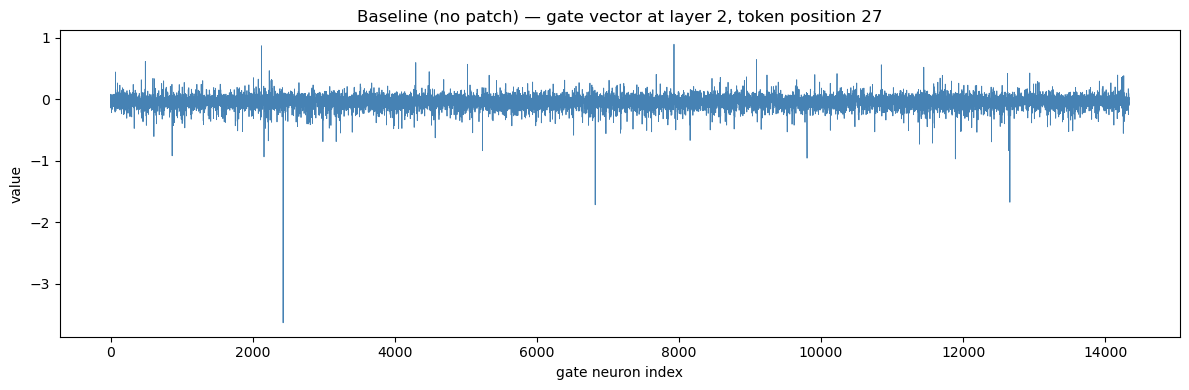

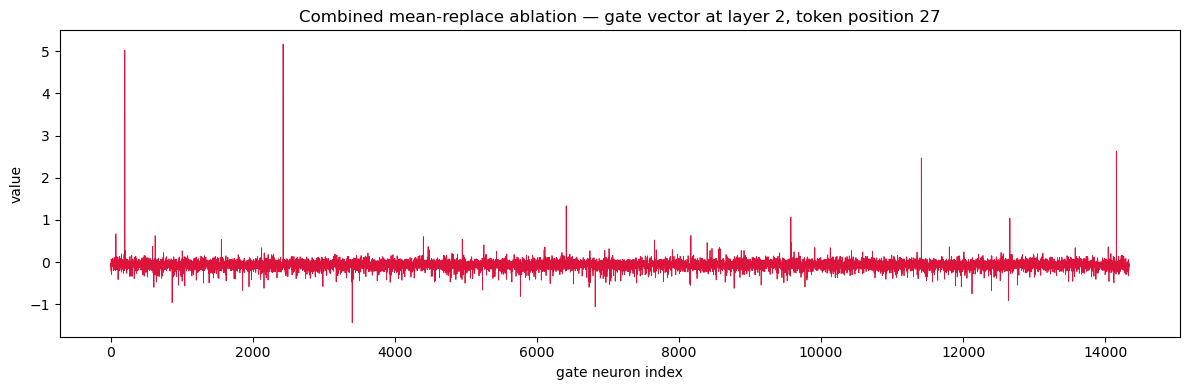

In [7]:
print(f"\n=== query pos {QUERY_POS} ===")

rows = [
    ("layer-1-only", results[0]['baseline']['gate'][NEURON_IDX], results[0]['intervention']['gate'][NEURON_IDX]),
    ("layer-2-only", results[1]['baseline']['gate'][NEURON_IDX], results[1]['intervention']['gate'][NEURON_IDX]),
    ("combined@L2",  results[1]['baseline']['gate'][NEURON_IDX], results['combined']['gate'][NEURON_IDX]),
]

print(f"{'condition':<14}{'gate base':>12}{'gate interv':>14}{'sign flip':>12}")
for name, base, interv in rows:
    flip = np.sign(base) != np.sign(interv)
    print(f"{name:<14}{base:>12.3f}{interv:>14.3f}{str(flip):>12}")

print(f"\npropagation-specific gate delta at layer 2 (combined - layer-2-only) = "
      f"{results['combined']['gate'][NEURON_IDX] - results[1]['intervention']['gate'][NEURON_IDX]:.4f}")

gate_baseline_L2 = results[1]['baseline']['gate']

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(gate_baseline_L2, linewidth=0.6, color='steelblue')
ax.set_title(f"Baseline (no patch) — gate vector at layer 2, token position {QUERY_POS}")
ax.set_xlabel("gate neuron index")
ax.set_ylabel("value")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"gate_vector_layer2_baseline_pos{QUERY_POS}.pdf"))
plt.show()

# fig, ax = plt.subplots(figsize=(12, 4))
# ax.plot(gate_layer2_only, linewidth=0.6, color='darkorange')
# ax.set_title(f"Layer-2-only mean-replace ablation — gate vector at layer 2, token position {QUERY_POS}")
# ax.set_xlabel("gate neuron index")
# ax.set_ylabel("value")
# plt.tight_layout()
# plt.savefig(os.path.join(OUTPUT_DIR, f"gate_vector_layer2_mean_replace_layer2only_pos{QUERY_POS}.pdf"))
# plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(results['combined']['gate'], linewidth=0.6, color='crimson')
ax.set_title(f"Combined mean-replace ablation — gate vector at layer 2, token position {QUERY_POS}")
ax.set_xlabel("gate neuron index")
ax.set_ylabel("value")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"gate_vector_layer2_mean_replace_combined_pos{QUERY_POS}.pdf"))
plt.show()

In [8]:
# Pick which condition's hidden-state stack to run the Finding-MA diagnostics on.
# Swap the right-hand side for baseline_hs / intervention_hs (per-layer, from the Steps 1-2
# loop -- last L in LAYERS_TO_TEST) to inspect a different condition.
hidden_states = combined_hs
print(f"using 'combined' hidden_states: {len(hidden_states)} tensors, shape {tuple(hidden_states[0].shape)}")

using 'combined' hidden_states: 33 tensors, shape (1, 28, 4096)


## Step 4 — Finding MA

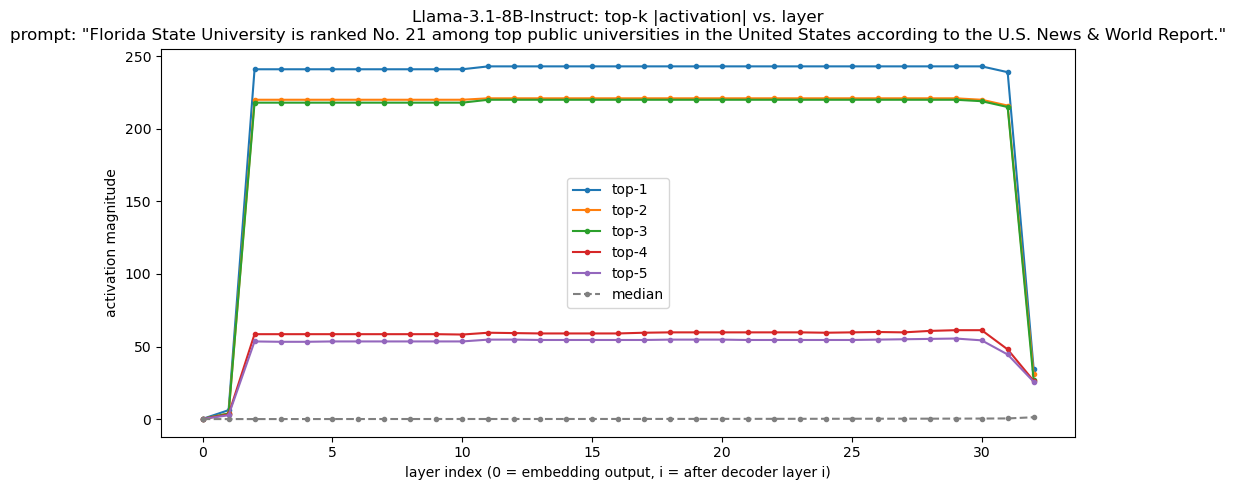

Layer with largest top-1 |activation|: 11 (value=243.0, median=0.067, ratio=3633x)


In [9]:
stats = np.zeros((6, len(hidden_states)))  # rows: top1..top5, median

for l, h in enumerate(hidden_states):
    feat_abs = h[0].float().abs()  # (T, d)
    flat_sorted, _ = torch.sort(feat_abs.flatten(), descending=True)
    
    stats[:5, l] = flat_sorted[:5].cpu().numpy()
    stats[5, l] = feat_abs.median().item()
    # print(stats[:5, l])

layer_axis = np.arange(len(hidden_states))  # 0 = embeddings, 1..L = after each decoder layer

fig, ax = plt.subplots(figsize=(10, 5))
for i, label in enumerate(["top-1", "top-2", "top-3", "top-4", "top-5"]):
    ax.plot(layer_axis, stats[i], marker="o", markersize=3, label=label)
ax.plot(layer_axis, stats[5], marker="o", markersize=3, label="median", linestyle="--", color="gray")
ax.set_xlabel("layer index (0 = embedding output, i = after decoder layer i)")
ax.set_ylabel("activation magnitude")
# ax.set_yscale("log")
ax.set_title(f"Llama-3.1-8B-Instruct: top-k |activation| vs. layer\nprompt: \"{PROMPT}\"")
ax.legend()
plt.tight_layout()
plt.show()

best_layer = int(np.argmax(stats[0]))
print(f"Layer with largest top-1 |activation|: {best_layer} "
      f"(value={stats[0, best_layer]:.1f}, median={stats[5, best_layer]:.3f}, "
      f"ratio={stats[0, best_layer] / max(stats[5, best_layer], 1e-8):.0f}x)")

In [10]:
def find_massive_activations(h, abs_thresh=100.0, ratio_thresh=1000.0):
    """h: (T, d) tensor for a single layer. Returns list of (token_idx, feat_idx, value)."""
    feat_abs = h.float().abs()
    med = feat_abs.median().item()
    mask = (feat_abs > abs_thresh) & (feat_abs > ratio_thresh * med)
    idxs = torch.nonzero(mask, as_tuple=False)
    results = [(int(t), int(i), feat_abs[t, i].item()) for t, i in idxs]
    results.sort(key=lambda r: -r[2])
    return results, med

LAYER_ID = best_layer # override manually if you want to inspect a specific layer instead
h_l = hidden_states[LAYER_ID][0]  # (T, d)

mas, layer_median = find_massive_activations(h_l)
print(f"Layer {LAYER_ID} — median |activation| = {layer_median:.4f}")
print(f"Found {len(mas)} massive activation(s):")
for t, i, v in mas:
    print(f"  token[{t}]=\"{tokens_decoded[t]}\"  feature_dim={i}  |activation|={v:.1f}")

Layer 11 — median |activation| = 0.0669
Found 3 massive activation(s):
  token[0]="Florida"  feature_dim=788  |activation|=243.0
  token[0]="Florida"  feature_dim=1384  |activation|=221.0
  token[0]="Florida"  feature_dim=4062  |activation|=220.0


### Step 4b - Draw a 3D plot

saved to outputs/mean_attention_ablation/3d_plots/llama31_8b_instruct_massive_activations_layer11.pdf


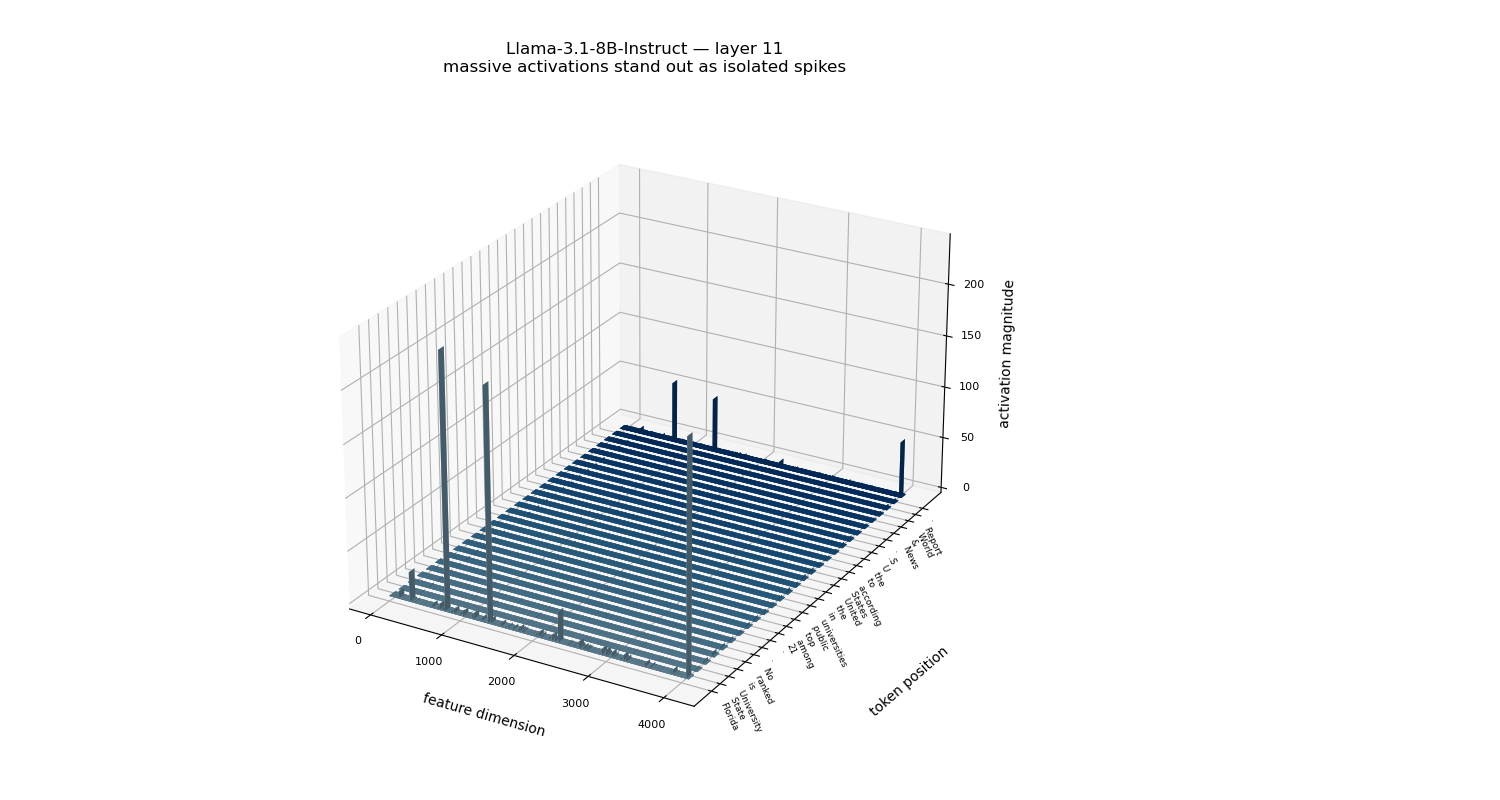

In [11]:
# Jupyter's inline backend renders with bbox_inches="tight", and matplotlib's 3d
# axes deliberately leave their axis labels out of that measurement
# (Axis3D.get_tightbbox is always called with for_layout_only=True), so the
# right-hand "activation magnitude" label gets sliced off. Turn the crop off.
%config InlineBackend.print_figure_kwargs = {'bbox_inches': None}

def plot_3d_feat(h, tokens_decoded, layer_id, model_name, savepath=None, elev=25, azim=-60,
                 tick_fontsize=None, tick_rotation=-65):
    """h: (T, d) tensor (already moved to CPU, float)."""
    feat_abs = h.float().abs().cpu().numpy()
    T, d = feat_abs.shape

    fig = plt.figure(figsize=(15, 8))
    ax = fig.add_subplot(111, projection="3d")
    # stretch the token axis so the per-token labels get more room on screen
    ax.set_box_aspect((1.0, 1.35, 0.75))

    xs = np.arange(d)
    dx = np.ones(d) * 1.0
    dy = np.ones(d) * 0.6
 
    colors = plt.cm.Blues(np.linspace(0.4, 0.9, T))

    for t in range(T):
        ys = np.full(d, t)
        zs = np.zeros(d)
        dz = feat_abs[t]
        ax.bar3d(xs, ys, zs, dx, dy, dz, color=colors[t], shade=True, edgecolor="none", alpha=0.9)

    ax.set_xlabel("feature dimension", labelpad=10)
    ax.set_ylabel("token position", labelpad=44)
    ax.set_zlabel("activation magnitude", labelpad=8)

    # token labels: shrink the font as the sequence grows and slant them roughly
    # perpendicular to the token axis so neighbours no longer overlap
    if tick_fontsize is None:
        tick_fontsize = max(4.0, min(7.5, 180.0 / max(T, 1)))
    tick_labels = []
    for tok in tokens_decoded:
        lbl = tok.replace("\n", "\\n").replace("\t", "\\t")
        tick_labels.append(lbl if lbl.strip() else "\u00b7")

    ax.set_yticks(np.arange(T))
    ax.set_yticklabels(tick_labels, fontsize=tick_fontsize, rotation=tick_rotation,
                       ha="left", va="center", rotation_mode="anchor")
    ax.tick_params(axis="y", pad=0.0)
    ax.tick_params(axis="x", labelsize=8)
    ax.tick_params(axis="z", labelsize=8)
    ax.set_title(f"{model_name} — layer {layer_id}\nmassive activations stand out as isolated spikes")
    ax.view_init(elev=elev, azim=azim)

    # tight_layout cannot measure 3d axis labels, so reserve the margins by hand
    fig.subplots_adjust(left=0.0, right=0.86, bottom=0.03, top=0.90)
    if savepath is not None:
        # no bbox_inches="tight": it cannot measure the 3d axis labels and crops them
        plt.savefig(savepath, dpi=200)
        print(f"saved to {savepath}")
    plt.show()


OUTPUT_DIR_3D = f"{OUTPUT_DIR}/3d_plots"
os.makedirs(OUTPUT_DIR_3D, exist_ok=True)
filename = "llama31_8b_instruct_massive_activations_layer%d.pdf" % LAYER_ID
full_path = os.path.join(OUTPUT_DIR_3D, filename)

plot_3d_feat(
    h_l.cpu(),
    tokens_decoded,
    LAYER_ID,
    "Llama-3.1-8B-Instruct",
    savepath=full_path,
)

## Interpretation

- **`layer-1-only` / `layer-2-only`**: whether collapsing that layer's attention to the
  cross-head average at query position 2 alone is sufficient to flip the sign of
  `gate[2427]`, independent of the other layer.
- **`combined@L2` vs. `layer-2-only`**: the propagation test, same logic as the masking
  notebook — a small delta means layer 2's own local intervention already accounts for
  the effect; a large delta means layer 1's intervention is propagating forward through
  the residual stream into layer 2's gate readout.
- **This isolates a specific hypothesis: does per-head specialization matter, or only
  the average behavior?** Unlike the masking notebook (which removes information by
  blocking specific keys) or the earlier uniform-attention draft (which is a foregone
  1/n regardless of data), this intervention keeps the *aggregate* information intact
  — the shared post-patch distribution is exactly what the average head would have
  produced — and only removes the *variation between heads*. If the gate value still
  flips sign under this patch, that's evidence the effect depends on the average
  attention pattern, not on any particular head's specialization. If it does *not*
  flip (unlike the masking result), that would suggest some specific head's deviation
  from the average is what's actually driving the original effect — information this
  patch destroys by design.
